# **Course co-enrollment Graphs**

We are going to explore **graphs based on student course enrollments** to gain insights into how courses are related through student enrollments/taken courses. 

The dataset is quite **heterogeneous**, which makes it challenging to infer detailed relationships, such as clear mappings between courses, programs, or departments. Additionally, the data is not limited to the RTU as it also includes **external data collected from other sources**, adding even more complexity to come up with this "mapping". 

However, building co-enrollment graphs provides a useful starting point to **visualize connections between courses and identify clusters of frequently co-taken courses**, even if deriving a precise hierarchy or fully accurate relationships is difficult. 


> [!NOTE]  
> Keep in mind that the clustering we obtain here is **not a definitive solution**. More important metadata is still needed, as graph-based approaches are not perfect. The groups of nodes identified simply represent courses that are **more densely connected to each other than to the rest of the network**, and should not be interpreted as a definitive/formal program relationship.

In [36]:
import pandas as pd
from educast.constants import  INTERIM_DATA_DIR

In [37]:
df = pd.read_csv(INTERIM_DATA_DIR / "flattened_grades_private.csv")
df.head()

/var/folders/zy/vwhqt1dn6bx96gfjzf8pt7qm0000gn/T/ipykernel_91188/1101935410.py:1: DtypeWarning: Columns (15,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INTERIM_DATA_DIR / "flattened_grades_private.csv")


,id,itemid,userid,rawgrade,rawgrademax,rawgrademin,rawscaleid,usermodified,finalgrade,hidden,...,aggregationcoef,sortorder,display,decimals,needsupdate,aggregationcoef2,weightoverride,_term,_course_id_dir,_source_file
0,526288,526288,165852,NaN,10.0,0.0,NaN,165852.0,NaN,0,...,1.0,5,0,NaN,0,0.0,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json
1,426388,426388,165852,NaN,10.0,0.0,NaN,NaN,0.0,0,...,0.0,1,0,NaN,0,0.0,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json
2,526255,526255,165852,NaN,10.0,0.0,NaN,NaN,NaN,0,...,1.0,2,0,NaN,0,0.0,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json
3,526268,526268,165852,NaN,10.0,0.0,NaN,NaN,NaN,0,...,1.0,3,0,NaN,0,0.0,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json
4,526287,526287,165852,NaN,10.0,0.0,NaN,NaN,NaN,0,...,1.0,4,0,NaN,0,0.0,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json


In [38]:
# For coenrollment analysis we just need userid and courseid
df_courses = (
    df[["userid", "courseid"]]
    .dropna(subset=["userid", "courseid"])
    .drop_duplicates()
)

print(df_courses.shape)
df_courses.head()

(88976, 2)


,userid,courseid
0,165852,144743
6,212799,144743
12,212268,144743
18,224350,157502
21,179098,157502


## **Co-enrolled courses**

We want to find **pairs of courses that students take together** and how many students are enrolled in each pair

Suppose we have students and their enrolled courses:

| userid | courses        |
|--------|----------------|
| 1      | [101, 102, 103] |
| 2      | [101, 104]      |

We generate **pairs of courses per student**:

| userid | course_pairs                     |
|--------|---------------------------------|
| 1      | [(101,102),(101,103),(102,103)] |
| 2      | [(101,104)]                      |

After applying `.explode()` each element within the list becomes an individual row

| userid | course_pairs |
|--------|-------------|
| 1      | (101,102)   |
| 1      | (101,103)   |
| 1      | (102,103)   |
| 2      | (101,104)   |

In [39]:
from itertools import combinations

pairs = (
    df_courses.groupby("userid")["courseid"]
    .apply(lambda x: list(combinations(sorted(x.unique()), 2)))
    .explode()
    .dropna()
)

co_enroll = pairs.value_counts().reset_index()
co_enroll.columns = ["pair", "weight"] # NOTE: The weight is the number of students co-enrolled in both courses
co_enroll["course_a"] = co_enroll["pair"].apply(lambda x: x[0])
co_enroll["course_b"] = co_enroll["pair"].apply(lambda x: x[1])

co_enroll.head()

,pair,weight,course_a,course_b
0,"(140790, 144243)",869,140790,144243
1,"(144536, 146690)",529,144536,146690
2,"(144545, 144550)",528,144545,144550
3,"(140790, 141999)",522,140790,141999
4,"(140790, 141722)",520,140790,141722


In [40]:
co_enroll.shape

(27016, 4)

## **Course co-enrollment Graph**

Once created the coenrollment pairs we can then create a **graph of courses** where edges represent how many students are enrolled in both courses. 

This helps visualize relationships between courses based on student co-enrollments.

In scpecific, an undirected graph where:
- Each node will represent a course.
- Each edge will represent a pair of courses taken by students together.

In [41]:
import networkx as nx

G = nx.Graph()
for _, row in co_enroll.iterrows():
    G.add_edge(row.course_a, row.course_b, weight=row.weight)

print(f"Graph has {G.number_of_nodes()} courses and {G.number_of_edges()} edges.")

Graph has 2611 courses and 27016 edges.


In [42]:
degree_df = pd.DataFrame(G.degree, columns=["courseid", "n_edges"]).sort_values("n_edges", ascending=False)
degree_df

,courseid,n_edges
1,144243,2603
37,139405,212
0,140790,189
75,157539,165
30,144971,157
...,...,...
2539,143158,1
2563,169010,1
2532,146170,1
2561,143568,1


In [43]:
# Community detection -> greedy modularity, in other words group of nodes that are more densely connected to each other than to the rest of the network
from networkx.algorithms.community import greedy_modularity_communities

communities = greedy_modularity_communities(G, weight="weight")

course_clusters = []
for i, comm in enumerate(communities):
    for c in comm:
        course_clusters.append({"courseid": c, "cluster_id": i})

df_clusters = pd.DataFrame(course_clusters)
print(df_clusters.shape)
df_clusters

(2611, 2)


,courseid,cluster_id
0,143360,0
1,141318,0
2,141331,0
3,141332,0
4,145438,0
...,...,...
2606,141866,34
2607,141909,34
2608,141878,34
2609,141850,34


In [44]:
df_clusters.cluster_id.value_counts()

cluster_id
0     629
1     256
2     184
3     184
4     161
5     153
6     116
7     111
8      94
9      81
10     64
11     64
12     61
13     50
14     46
15     43
16     39
17     31
18     30
19     26
20     25
21     21
22     17
23     16
24     16
25     16
26     14
27     12
28     12
29      9
30      7
31      6
32      6
33      6
34      5
Name: count, dtype: int64

In [45]:
df_clusters["cluster_id"].value_counts().sort_index().head(10)

cluster_id
0    629
1    256
2    184
3    184
4    161
5    153
6    116
7    111
8     94
9     81
Name: count, dtype: int64

Cluster 0: 629 courses, 3535 links


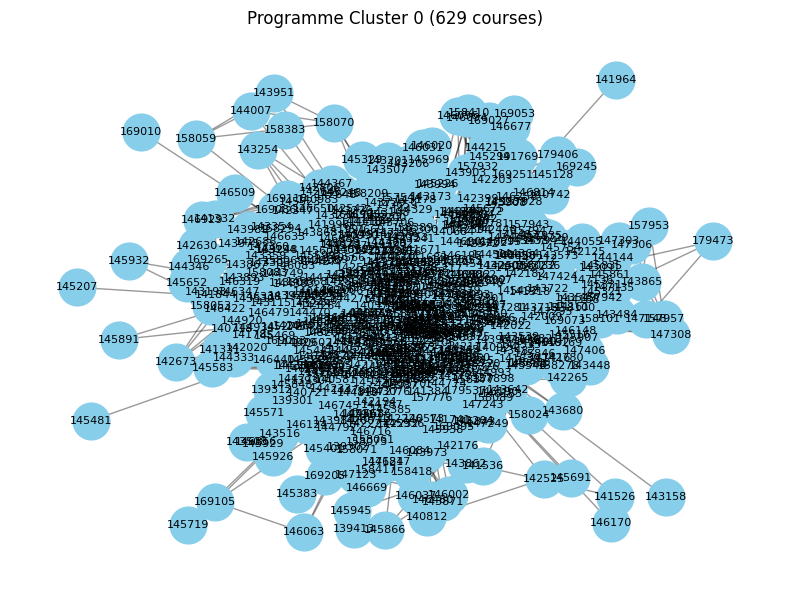

In [46]:
import matplotlib.pyplot as plt

cluster_id = 0
cluster_courses = df_clusters.loc[df_clusters["cluster_id"] == cluster_id, "courseid"].tolist()

subG = G.subgraph(cluster_courses)
print(f"Cluster {cluster_id}: {len(subG.nodes())} courses, {len(subG.edges())} links")

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(subG, seed=42)

nx.draw_networkx_nodes(subG, pos, node_color='skyblue', node_size=700)
nx.draw_networkx_edges(subG, pos, alpha=0.4)
nx.draw_networkx_labels(subG, pos, font_size=8)

plt.title(f"Programme Cluster {cluster_id} ({len(subG.nodes())} courses)")
plt.axis("off")
plt.tight_layout()
plt.show()

Cluster 10: 64 courses, 399 links


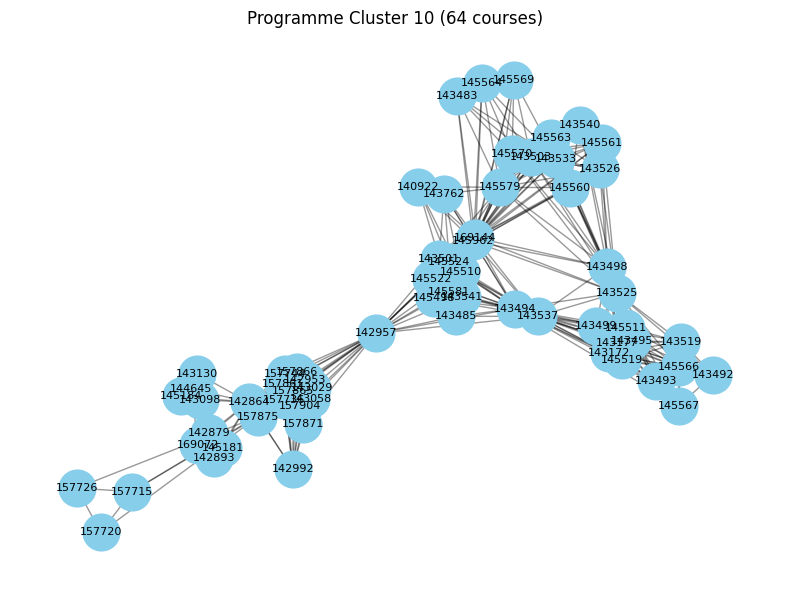

In [47]:
import matplotlib.pyplot as plt

cluster_id = 10
cluster_courses = df_clusters.loc[df_clusters["cluster_id"] == cluster_id, "courseid"].tolist()

subG = G.subgraph(cluster_courses)
print(f"Cluster {cluster_id}: {len(subG.nodes())} courses, {len(subG.edges())} links")

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(subG, seed=42)

nx.draw_networkx_nodes(subG, pos, node_color='skyblue', node_size=700)
nx.draw_networkx_edges(subG, pos, alpha=0.4)
nx.draw_networkx_labels(subG, pos, font_size=8)

plt.title(f"Programme Cluster {cluster_id} ({len(subG.nodes())} courses)")
plt.axis("off")
plt.tight_layout()
plt.show()

In [48]:
sampled_courses = (
    df_clusters.groupby("cluster_id")
    .head(1) # Smpled 1 course per cluster
    .courseid.tolist()
)

sample_subG = G.subgraph(sampled_courses)
print(f"Sampled subgraph: {len(sample_subG.nodes())} courses, {len(sample_subG.edges())} edges.")

Sampled subgraph: 35 courses, 0 edges.


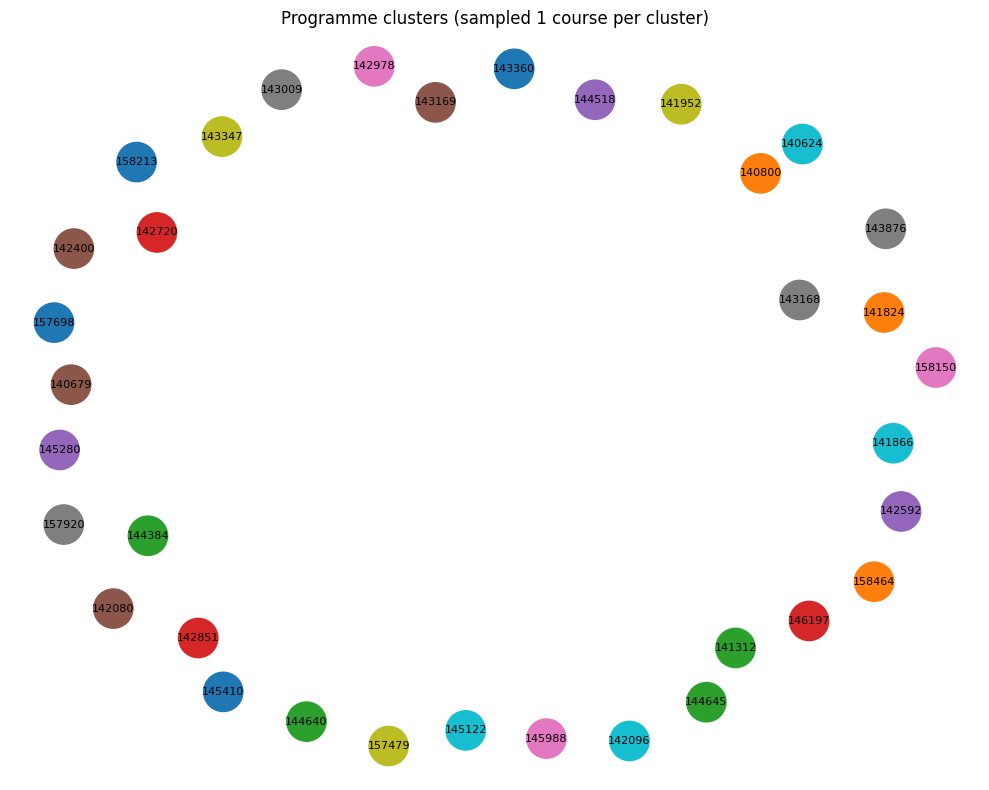

In [49]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(sample_subG, seed=42)

node_colors = [
    df_clusters.set_index("courseid").loc[n, "cluster_id"] for n in sample_subG.nodes
]

nx.draw_networkx_nodes(sample_subG, pos, node_color=node_colors, cmap="tab10", node_size=800)
nx.draw_networkx_edges(sample_subG, pos, alpha=0.4)
nx.draw_networkx_labels(sample_subG, pos, font_size=8)

plt.title("Programme clusters (sampled 1 course per cluster)")
plt.axis("off")
plt.tight_layout()
plt.show()

Building a graph based on student co-enrollments is a useful starting point to explore which courses are more closely connected to each other. 

However, this approach can introduce errors and mismatches in the data, and it is challenging to derive/inferr a clear hierarchy of courses and university departments directly from it. What's clear is that the most important thing to correctly distinguish are the different programs within the data and ensure the dataset is consistent.

> [!NOTE]
> Some course IDs within the data may be inconsistent across files, for example, `21-22R.txt` contains fewer IDs (in the order of the 400 courses) than the main dataset (in the order of 1500 courses)